# CIHA: atendimentos além do SUS

**Pergunta que este notebook responde:** o que a Comunicação de Internação
Hospitalar e Ambulatorial registra, e como ela complementa o SIH?

**Fonte:** CIHA — registra atendimentos realizados por estabelecimentos que
atendem **também fora do SUS** (convênios e particulares), permitindo enxergar
parte da assistência que não aparece no SIH.
**Tempo estimado:** 3 a 5 minutos.

> ⚠️ **Armadilha desta base:** a função `ciha()` tem `group="CIHA"` como valor
> padrão, e esse valor **faz a consulta devolver zero linhas**. É preciso passar
> `group=None` explicitamente.

## Preparação

In [2]:
%pip install pysus==2.10.6 nest_asyncio -q
import nest_asyncio
nest_asyncio.apply()
print("Ambiente pronto.")

Note: you may need to restart the kernel to use updated packages.
Ambiente pronto.


## Parâmetros

In [3]:
UF = "PR"
ANO = 2023
MES = 1

## Passo 1 — Conferir o catálogo

In [4]:
from pysus import list_files

catalogo = list_files(dataset="ciha", state=UF, year=ANO)
arquivos = sorted(nome.split("\\")[-1] for nome in catalogo["name"])

print(f"Arquivos em {UF}/{ANO}: {len(arquivos)}")
print("Exemplos:", arquivos[:4])

Arquivos em PR/2023: 12
Exemplos: ['CIHAPR2301.parquet', 'CIHAPR2302.parquet', 'CIHAPR2303.parquet', 'CIHAPR2304.parquet']


## Passo 2 — Baixar (com `group=None`)

In [5]:
from pysus import ciha

atendimentos = ciha(state=UF, year=ANO, month=MES, group=None, as_dataframe=True)

print(f"{len(atendimentos):,} atendimentos em {UF}, {MES:02d}/{ANO}")
print(f"{len(atendimentos.columns)} colunas")
print()
print("Se o resultado acima for 0, confira se você passou group=None.")

110,862 atendimentos em PR, 01/2023
30 colunas

Se o resultado acima for 0, confira se você passou group=None.


In [6]:
list(atendimentos.columns)

['ANO_CMPT',
 'MES_CMPT',
 'ESPEC',
 'CGC_HOSP',
 'MUNIC_RES',
 'NASC',
 'SEXO',
 'UTI_MES_TO',
 'UTI_INT_TO',
 'PROC_REA',
 'QT_PROC',
 'DT_ATEND',
 'DT_SAIDA',
 'DIAG_PRINC',
 'DIAG_SECUN',
 'COBRANCA',
 'NATUREZA',
 'GESTAO',
 'MUNIC_MOV',
 'COD_IDADE',
 'IDADE',
 'DIAS_PERM',
 'MORTE',
 'NACIONAL',
 'CAR_INT',
 'HOMONIMO',
 'CNES',
 'FONTE',
 'CGC_CONSOR',
 'MODALIDADE']

## Passo 3 — Principais diagnósticos

In [7]:
import pandas as pd

top = (
    atendimentos["DIAG_PRINC"]
    .value_counts()
    .head(12)
    .rename_axis("CID-10")
    .reset_index(name="Atendimentos")
)
top["%"] = (top["Atendimentos"] / len(atendimentos) * 100).round(2)
top

,CID-10,Atendimentos,%
0,,45962,41.46
1,Z000,9904,8.93
2,A000,5540,5.00
3,Z049,3358,3.03
4,R103,1227,1.11
5,Z010,1193,1.08
6,A09,924,0.83
7,R104,842,0.76
8,Z008,833,0.75
9,M125,829,0.75


## Passo 4 — Perfil por sexo e idade

In [8]:
SEXOS = {"1": "Masculino", "3": "Feminino", "2": "Feminino", "0": "Ignorado", "9": "Ignorado"}

perfil = (
    atendimentos["SEXO"].astype(str).map(SEXOS).fillna("Ignorado")
    .value_counts()
    .rename_axis("Sexo")
    .reset_index(name="Atendimentos")
)
perfil["%"] = (perfil["Atendimentos"] / len(atendimentos) * 100).round(1)
perfil

,Sexo,Atendimentos,%
0,Feminino,60415,54.5
1,Masculino,38700,34.9
2,Ignorado,11747,10.6


## Passo 5 — Procedimentos e permanência

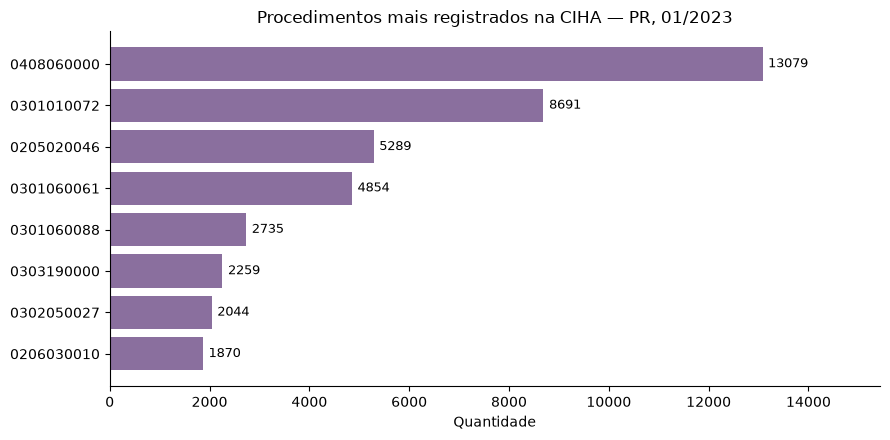

In [9]:
import matplotlib.pyplot as plt

proc = (
    atendimentos["PROC_REA"]
    .value_counts()
    .head(8)
    .rename_axis("Procedimento")
    .reset_index(name="Quantidade")
    .sort_values("Quantidade")
)

fig, ax = plt.subplots(figsize=(9, 4.5))
barras = ax.barh(proc["Procedimento"].astype(str), proc["Quantidade"], color="#8a6f9e")
ax.bar_label(barras, padding=4, fontsize=9)
ax.set_title(f"Procedimentos mais registrados na CIHA — {UF}, {MES:02d}/{ANO}", fontsize=12)
ax.set_xlabel("Quantidade")
ax.set_xlim(0, proc["Quantidade"].max() * 1.18)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Como interpretar

A CIHA **não substitui o SIH**: ela cobre estabelecimentos que atendem fora do
SUS e cuja notificação é obrigatória, mas a cobertura varia muito entre estados
e períodos. Use-a como complemento, não como fonte única.

## Como adaptar

- **Outro estado, ano ou mês:** mude os parâmetros — lembrando sempre de
  `group=None`.
- **Um diagnóstico específico:** filtre `DIAG_PRINC`.
- **Por município:** agrupe por `MUNIC_RES`.

---
*Notebook do projeto [PySusNoCode](https://github.com/cartaproale/PySusNoCode) —
um produto [Kraemer Academy](https://kraemeracademy.net).
Validado com dados reais do DATASUS.*